In [ ]:
# Credit Card Fraud Detection - Gradient Boosting

Binary classification on the highly imbalanced [Credit Card Fraud](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) dataset (~0.17% fraud).

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub

from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

In [2]:
# ==========================================
# Download dataset from Kaggle
# ==========================================
#
# About the dataset (mlg-ulb/creditcardfraud):
#   - Real credit card transactions by European cardholders over 2 days
#     in September 2013.
#   - 284,807 transactions in total, of which only 492 are fraud (~0.17%).
#     This extreme imbalance is the central challenge of the problem.
#
# Columns (31 total):
#   - Time    : seconds elapsed since the first transaction in the dataset.
#   - V1-V28  : 28 anonymized numeric features. The original details
#               (merchant, location, etc.) were private, so they were
#               transformed via PCA into these unnamed components.
#   - Amount  : the transaction amount in euros.
#   - Class   : the target -> 0 = legitimate, 1 = fraud.

path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
print("Dataset downloaded to:", path)

# Locate and load CSV file
csv_file = os.path.join(path, "creditcard.csv")
df = pd.read_csv(csv_file)

print("\nDataset Shape:", df.shape)
print(df.head())

Dataset downloaded to: C:\Users\91720\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3

Dataset Shape: (284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.17557

In [3]:
# ==========================================
# Inspect class balance
# ==========================================
# Class 1 = fraud, Class 0 = legitimate. This is extremely imbalanced.

counts = df["Class"].value_counts()
fraud_pct = 100 * counts.get(1, 0) / len(df)

print("Class distribution:")
print(counts)
print(f"\nFraud rate: {fraud_pct:.3f}%")

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud rate: 0.173%


In [4]:
# ==========================================
# 1. Quick data health check
# ==========================================
print("Missing values per column (top 5):")
print(df.isnull().sum().sort_values(ascending=False).head())

print("\nSummary of Amount and Time:")
print(df[["Amount", "Time"]].describe())

Missing values per column (top 5):
Time    0
V1      0
V2      0
V3      0
V4      0
dtype: int64

Summary of Amount and Time:
              Amount           Time
count  284807.000000  284807.000000
mean       88.349619   94813.859575
std       250.120109   47488.145955
min         0.000000       0.000000
25%         5.600000   54201.500000
50%        22.000000   84692.000000
75%        77.165000  139320.500000
max     25691.160000  172792.000000


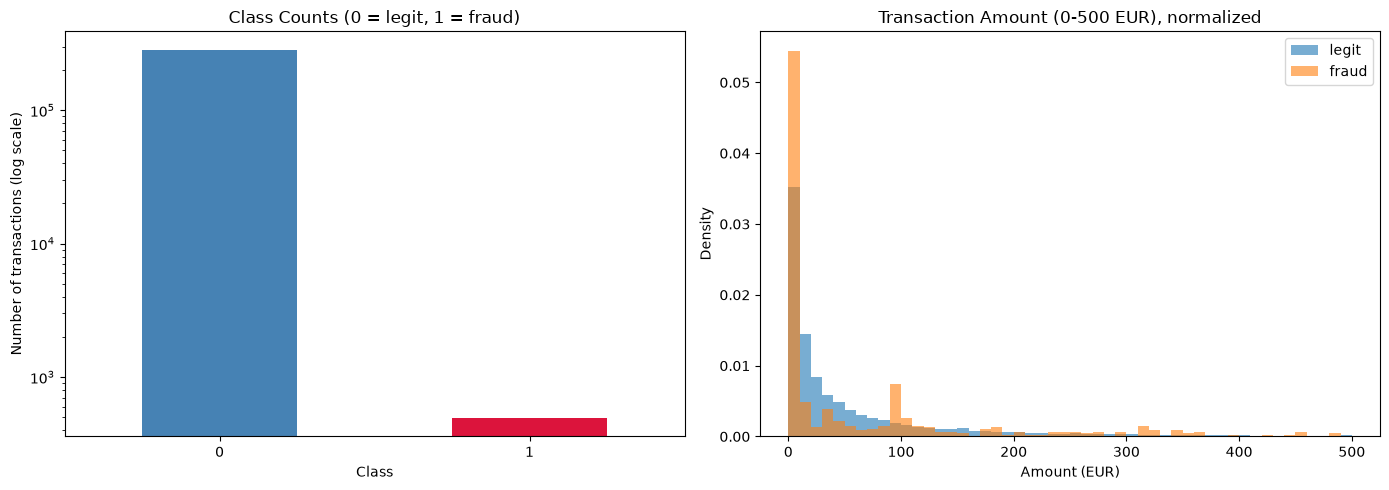

In [5]:
# ==========================================
# 2. Visualize class imbalance + Amount distribution
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: how many of each class (log scale, since fraud is so rare)
counts.plot(kind="bar", ax=axes[0], color=["steelblue", "crimson"])
axes[0].set_title("Class Counts (0 = legit, 1 = fraud)")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Number of transactions (log scale)")
axes[0].set_yscale("log")
axes[0].tick_params(axis="x", rotation=0)

# Right: transaction amount, fraud vs legit (zoomed to 0-500 EUR, normalized)
legit_amounts = df.loc[df["Class"] == 0, "Amount"]
fraud_amounts = df.loc[df["Class"] == 1, "Amount"]
axes[1].hist(legit_amounts, bins=50, range=(0, 500), alpha=0.6, label="legit", density=True)
axes[1].hist(fraud_amounts, bins=50, range=(0, 500), alpha=0.6, label="fraud", density=True)
axes[1].set_title("Transaction Amount (0-500 EUR), normalized")
axes[1].set_xlabel("Amount (EUR)")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.show()

In [6]:
# ==========================================
# 3. Compare average Amount: fraud vs legit
# ==========================================
print("Transaction amount by class:")
print(df.groupby("Class")["Amount"].agg(["mean", "median", "max"]))

Transaction amount by class:
             mean  median       max
Class                              
0       88.291022   22.00  25691.16
1      122.211321    9.25   2125.87


In [7]:
# ==========================================
# Features and Target
# ==========================================
X = df.drop("Class", axis=1)
y = df["Class"]

# ==========================================
# Train/Test Split (stratified to preserve fraud ratio)
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 227845
Testing Samples: 56962


In [8]:
# ==========================================
# Gradient Boosting Model (XGBoost, CPU)
# ==========================================
# XGBoost is the go-to gradient booster for tabular, imbalanced data.
# Instead of class_weight, it exposes `scale_pos_weight`, which up-weights
# the rare fraud class. The standard rule of thumb is:
#     scale_pos_weight = (# negatives) / (# positives)
# so the gradients from the few fraud cases roughly balance the many legit ones.
#
# tree_method="hist" + device="cpu" keeps this on the CPU (fast, multi-core)
# without needing a GPU.

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"scale_pos_weight = {scale_pos_weight:.1f}  (neg={neg}, pos={pos})")

gb_model = XGBClassifier(
    n_estimators=100,          # number of boosting rounds
    learning_rate=0.1,
    max_depth=3,
    scale_pos_weight=scale_pos_weight,
    tree_method="hist",        # histogram-based, fast on CPU
    device="cpu",
    eval_metric="aucpr",       # PR-AUC, the right metric for imbalanced data
    n_jobs=-1,
    random_state=42,
)

gb_model.fit(X_train, y_train)

# Predictions
y_pred = gb_model.predict(X_test)
y_prob = gb_model.predict_proba(X_test)[:, 1]

scale_pos_weight = 577.3  (neg=227451, pos=394)


In [9]:
# ==========================================
# Evaluation
# ==========================================
print("\n==============================")
print("MODEL PERFORMANCE")
print("==============================")

print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1 Score :", round(f1_score(y_test, y_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob), 4))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred, target_names=["legit", "fraud"]))


MODEL PERFORMANCE
Accuracy : 0.9932
Precision: 0.1867
Recall   : 0.8878
F1 Score : 0.3085
ROC-AUC  : 0.979

Confusion Matrix
[[56485   379]
 [   11    87]]

Classification Report
              precision    recall  f1-score   support

       legit       1.00      0.99      1.00     56864
       fraud       0.19      0.89      0.31        98

    accuracy                           0.99     56962
   macro avg       0.59      0.94      0.65     56962
weighted avg       1.00      0.99      1.00     56962



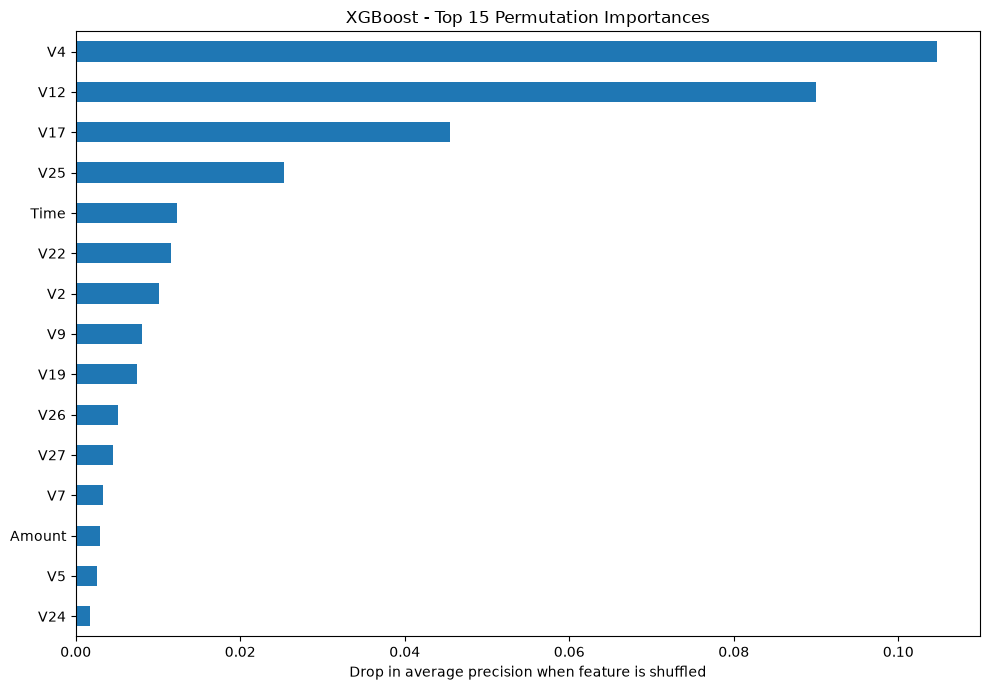

In [10]:
# ==========================================
# Visualize the Model: Feature Importances (permutation)
# ==========================================
# XGBoost has a built-in feature_importances_ (based on split gain), but that
# can be biased toward high-cardinality features. PERMUTATION importance is
# more trustworthy: shuffle one feature's values and see how much the model's
# score drops. A big drop = important feature. We score on a 10,000-row sample
# of the test set using average precision (PR-AUC) to keep it fast and on-metric.

sample = X_test.sample(10000, random_state=42)
sample_y = y_test.loc[sample.index]

perm = permutation_importance(
    gb_model, sample, sample_y,
    scoring="average_precision",   # good metric for imbalanced data
    n_repeats=5,
    random_state=42,
    n_jobs=-1,
)

importances = (
    pd.Series(perm.importances_mean, index=X.columns)
    .sort_values(ascending=True)
    .tail(15)  # top 15 features
)

plt.figure(figsize=(10, 7))
importances.plot(kind="barh")
plt.title("XGBoost - Top 15 Permutation Importances")
plt.xlabel("Drop in average precision when feature is shuffled")
plt.tight_layout()
plt.show()